In [49]:
from pathlib import Path
import pickle


beta_strength = 0.1 # (0.1 0.15 0.2 0.25 0.3 0.0  0.6)
n=3000
regressor_name = "gb" # "lasso" "gb" 


results_dir = Path("../results/csv/simulations")

files = sorted(
    results_dir.glob(
        f"simulations_dirich_beta{beta_strength}_model{regressor_name}_n{n}_seed*_martingales.pkl"
    )
)

all_martingales = []

for file in files:
    with open(file, "rb") as f:
        all_martingales.append(pickle.load(f))

print(f"Loaded {len(all_martingales)} seeds.")

Loaded 5 seeds.


In [50]:
all_martingales

[{'exponential': {2: {0: array([  1.        ,   1.        ,   1.        , ..., 193.93495622,
           249.36716497, 249.36716497], shape=(3000,))},
   5: {0: array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
           1.30417247e+03, 1.30417247e+03, 1.30417247e+03], shape=(3000,))},
   10: {0: array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
           7.77626681e+03, 7.77626681e+03, 7.77626681e+03], shape=(3000,))},
   20: {0: array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
           3.28590712e+03, 3.28590712e+03, 3.28590712e+03], shape=(3000,))}},
  'coin_betting': {2: {0: array([  1.        ,   1.        ,   1.        , ..., 147.29258837,
           186.42536894, 186.42536894], shape=(3000,))},
   5: {0: array([  1.        ,   1.        ,   1.        , ..., 233.83486172,
           233.83486172, 233.83486172], shape=(3000,))},
   10: {0: array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
           8.80730413e+04, 8.80730413e+04, 8.8073

In [51]:
import numpy as np

mean_martingales = {}

for strategy in all_martingales[0]:
    mean_martingales[strategy] = {}
    for batch in all_martingales[0][strategy]:
        mean_martingales[strategy][batch] = {}

        for j in all_martingales[0][strategy][batch]:
            arrays = [
                m[strategy][batch][j]
                for m in all_martingales
            ]
            mean_martingales[strategy][batch][j] = np.mean(arrays, axis=0)

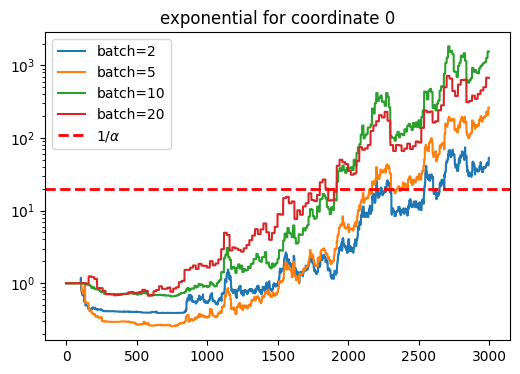

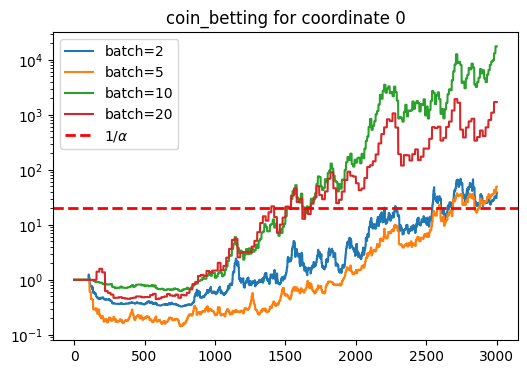

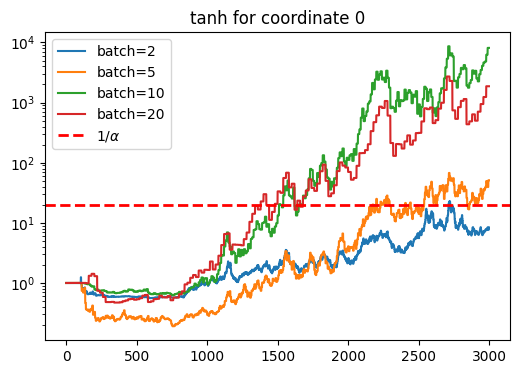

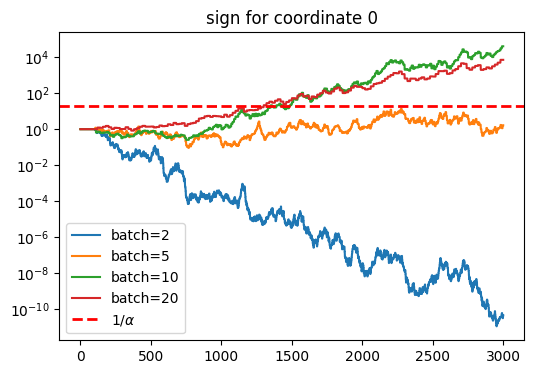

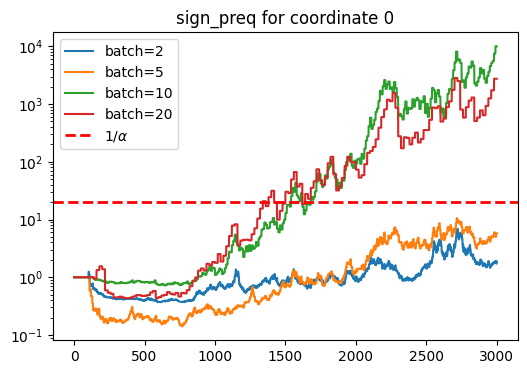

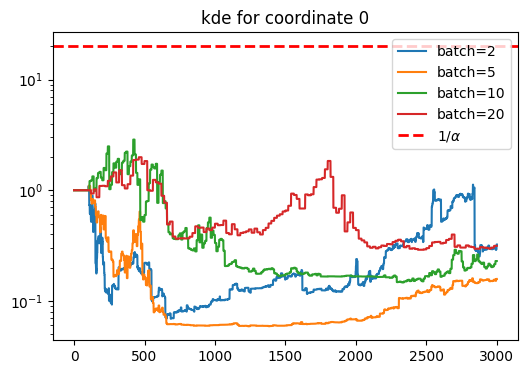

In [52]:
import matplotlib.pyplot as plt
alpha = 0.05
batch_list = [2, 5, 10, 20]
for j in [0]:
    for strategy_name in all_martingales[0]:
        plt.figure(figsize=(6, 4))
        for b in batch_list:
            plt.plot(
                mean_martingales[strategy_name][b][j],
                label=f"batch={b}"
            )
        plt.yscale("log")
        plt.title(f"{strategy_name} for coordinate {j}")
        plt.axhline(
            y=1/alpha,
            color="red",
            linestyle="--",
            linewidth=2,
            label=r"$1/\alpha$"
        )
        plt.legend()
        plt.show()

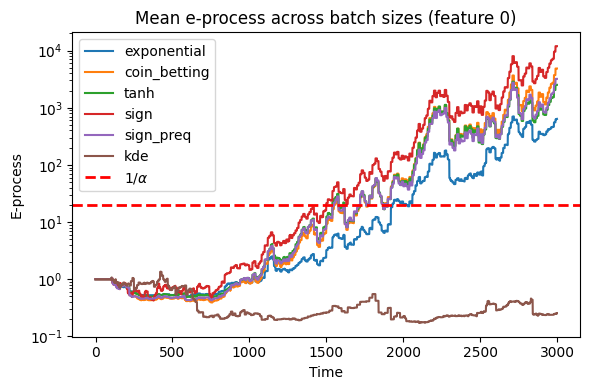

In [53]:
plt.figure(figsize=(6, 4))
batch_list = [2, 5, 10, 20]

for j in [0]:
    for strategy_name in all_martingales[0]:
        mean_process = np.mean(
            [mean_martingales[strategy_name][b][j] for b in batch_list],
            axis=0
        )

        plt.plot(mean_process, label=strategy_name)

    plt.axhline(
        y=1 / alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )

    plt.yscale("log")
    plt.xlabel("Time")
    plt.ylabel("E-process")
    plt.title(f"Mean e-process across batch sizes (feature {j})")
    plt.legend()
    plt.tight_layout()
    plt.show()